## Acknowledgement

The problem setup and initial section of this notebook was provided by my course instructor at IIT Hyderabad.

All further work, including data analysis, feature evaluation, and implementations, has been carried out independently.

# Microstructure Doppelgängers — Similar Summaries, Different Evolution Laws

## Objective
In this project, we investigate a subtle but important question in microstructure analysis:

Can two microstructures have similar low-order summaries, such as phase fraction and rough length scale, and yet arise from fundamentally different evolution laws?

To study this, we compare two families of two-dimensional microstructures:

- one family generated using a simple **Cahn–Hilliard** evolution,
- one family generated using a simple **Allen–Cahn** evolution.

These two equations represent different physical ideas.

In a Cahn–Hilliard setting, the field is **conserved**, which makes it a natural toy model for phase separation and composition redistribution. Even if the initial condition looks nearly uniform apart from small noise, the system can evolve into interconnected patterns while preserving the overall average composition.

In an Allen–Cahn setting, the field is **nonconserved**, which makes it a natural toy model for ordering, domain evolution, or interface motion. Starting from a nearly uniform field with small noise, the system can still separate into domains, but the morphology and the role of conservation are different.

## The scientific puzzle
We will generate two families of microstructures and tune them so that they have roughly similar:
- area fraction,
- and a comparable visual scale.

The puzzle is then this:

> If two microstructures have similar phase fraction and similar rough scale, are they really equivalent?

Or more sharply:

> What information about mechanism is missed when we summarize a microstructure too aggressively?

## Why this is interesting
This project teaches a deep lesson:

> Similar summary statistics do not imply similar physics.

Two microstructures may have similar area fraction and similar characteristic size, yet differ in:
- connectivity,
- topology,
- interface arrangement,
- and likely transport or mechanical response.

So the aim is not merely to look at images, but to ask whether higher-order morphology retains evidence of the underlying evolution law.

## What this notebook does
This notebook begins with a synthetic generator that creates:
- Cahn–Hilliard patterns from a conserved field $begin:math:text$c\(x\,y\)$end:math:text$,
- Allen–Cahn patterns from a nonconserved field $begin:math:text$\\phi\(x\,y\)$end:math:text$,

with both fields initialized near $begin:math:text$0\.5$end:math:text$ plus small random noise.

Both fields evolve under a double-well free energy:
- $begin:math:text$g\(c\) \= W\_c c\^2 \(1\-c\)\^2$end:math:text$ for the conserved field,
- $begin:math:text$f\(\\phi\) \= W\_\\phi \\phi\^2 \(1\-\\phi\)\^2$end:math:text$ for the nonconserved field.

The result is a controlled dataset of microstructure “doppelgängers”:
patterns that may look similar under crude summaries, yet are not generated by the same type of dynamics.

## What to look for
As you inspect the generated structures, ask:

- Which family is more interconnected?
- Does one family form more rounded or more tortuous domains?
- If phase fraction is similar, what still distinguishes the two?
- Would one or two scalar descriptors be enough to separate them?
- If we later apply PCA or SVD to the full images, will the two families separate more clearly than simple summaries suggest?

This project is therefore about **conservation law, morphology, topology, and the limits of low-order summary statistics**.

**Note**: the final binary fields are thresholded by quantile so that the area fraction is deliberately comparable across families. This is done to prevent one trivial summary statistic from dominating the comparison.

Summary table:


,sample_id,family,area_fraction,interface_density,nn_correlation_proxy
0,CH0,cahn_hilliard,0.450012,0.172668,0.406588
1,CH1,cahn_hilliard,0.450012,0.191589,0.401882
2,CH2,cahn_hilliard,0.450012,0.203003,0.399822
3,CH3,cahn_hilliard,0.450012,0.184326,0.403451
4,CH4,cahn_hilliard,0.450012,0.191162,0.401821
5,CH5,cahn_hilliard,0.450012,0.177917,0.405819
6,CH6,cahn_hilliard,0.450012,0.205200,0.397730
7,CH7,cahn_hilliard,0.450012,0.179810,0.404466
8,CH8,cahn_hilliard,0.450012,0.192993,0.402190
9,CH9,cahn_hilliard,0.450012,0.172363,0.406342



Grouped summary:


area_fraction      interface_density            \
                       mean  std              mean       std   
family                                                         
allen_cahn         0.450012  0.0          0.188303  0.009931   
cahn_hilliard      0.450012  0.0          0.187408  0.009506   

              nn_correlation_proxy            
                              mean       std  
family                                        
allen_cahn                0.402677  0.002397  
cahn_hilliard             0.402847  0.002411

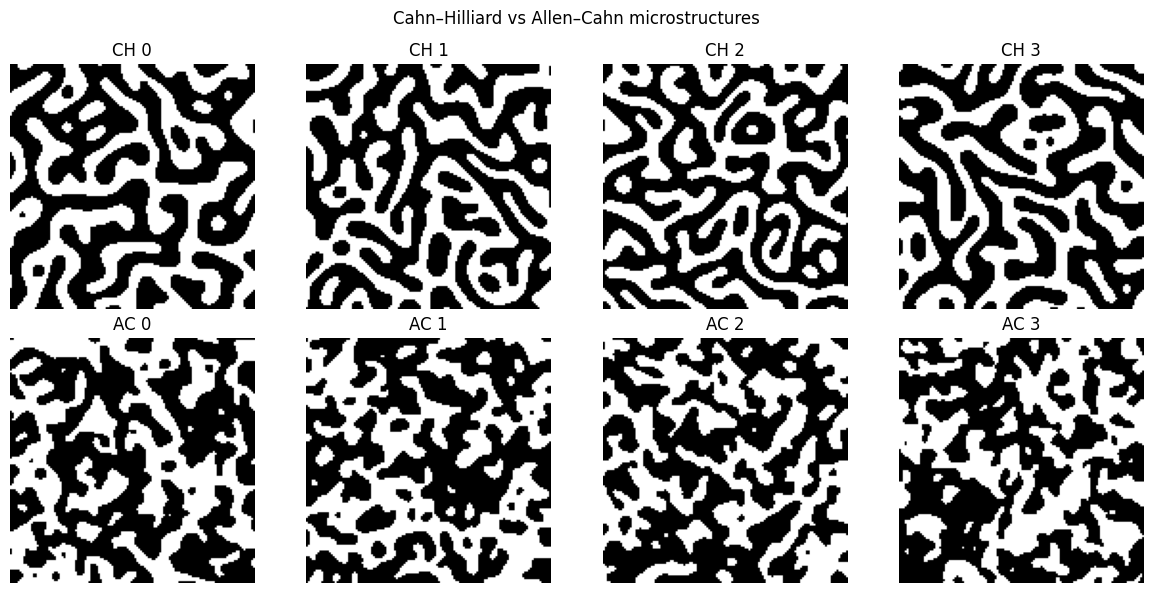

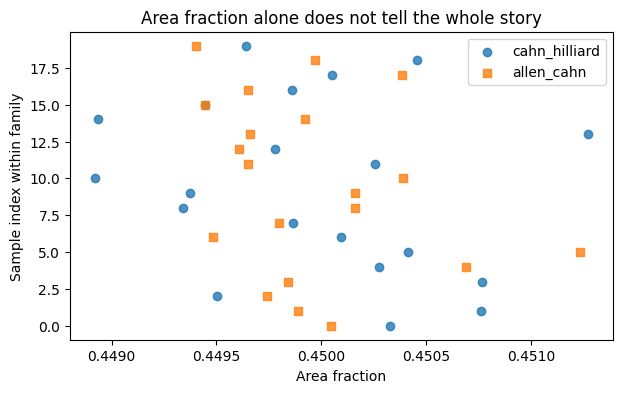

Image matrix shape for later PCA/SVD: (40, 16384)

Questions to think about:
1. Do similar area fraction and interface density imply similar physics?
2. Does one family appear more interconnected or more tortuous than the other?
3. If low-order summaries overlap, what information is missing?
4. Would PCA or SVD on the full images reveal structure that the summary table misses?
5. If transport depended on connectivity, would these two families still be equivalent?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2028)

# We generate two families of 2D microstructures.
#
# One family evolves by Cahn–Hilliard dynamics:
# the field c is conserved, so its spatial average should remain nearly fixed.
#
# The other evolves by Allen–Cahn dynamics:
# the field phi is not conserved, so the dynamics can reorganize the pattern
# without preserving the global mean in the same way.
#
# Both start from 0.5 plus small uniform noise.
# That keeps the initial condition smooth and avoids the spectral artifacts
# caused by sharp seeded interfaces.

nx, ny = 128, 128
dx = 1.0
dy = 1.0

n_each = 20 #increase this for more samples, but can increase runtime and memory
target_fraction = 0.45

dt_ch = 0.15
dt_ac = 0.01

Wc = 6.0
Wp = 6.0
kappa_c = 2.0
kappa_phi = 1.6

M = 1.0
L = 1.0

kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx).reshape(-1, 1)
ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy).reshape(1, -1)
k2 = kx**2 + ky**2
k4 = k2**2


def dgdc(c):
    """Derivative of g(c) = Wc * c^2 * (1-c)^2."""
    return Wc * 2.0 * c * (1.0 - c) * (1.0 - 2.0 * c)


def dfdphi(phi):
    """Derivative of f(phi) = Wp * phi^2 * (1-phi)^2."""
    return Wp * 2.0 * phi * (1.0 - phi) * (1.0 - 2.0 * phi)


def generate_noisy_initial_field(nx=128, ny=128, mean_value=0.5, noise_amp=0.02):
    """
    Generate a smooth initial field near 0.5 with small uniform noise.
    """
    field = mean_value + noise_amp * (rng.random((nx, ny)) - 0.5)
    return np.clip(field, 0.0, 1.0)


def evolve_cahn_hilliard(c, nsteps=300):
    """
    Semi-implicit Fourier spectral update for

        dc/dt = M ∇²( dg/dc - kappa_c ∇²c )

    with
        c_hat^{n+1} =
        [ c_hat^n - dt M k^2 FFT(dg/dc(c^n)) ] / [ 1 + dt M kappa_c k^4 ]
    """
    c = c.copy()

    for _ in range(nsteps):
        nonlinear_hat = np.fft.fft2(dgdc(c))
        c_hat = np.fft.fft2(c)

        c_hat_new = (c_hat - dt_ch * M * k2 * nonlinear_hat) / (1.0 + dt_ch * M * kappa_c * k4)
        c = np.real(np.fft.ifft2(c_hat_new))

        # For this teaching notebook, gentle clipping is acceptable.
        c = np.clip(c, 0.0, 1.0)

    return c


def evolve_allen_cahn(phi, nsteps=180):
    """
    Semi-implicit Fourier spectral update for

        dphi/dt = -L ( dfdphi - kappa_phi ∇²phi )

    with
        phi_hat^{n+1} =
        [ phi_hat^n - dt L FFT(dfdphi(phi^n)) ] / [ 1 + dt L kappa_phi k^2 ]
    """
    phi = phi.copy()

    for step in range(nsteps):
        nonlinear_hat = np.fft.fft2(dfdphi(phi))
        phi_hat = np.fft.fft2(phi)

        phi_hat_new = (phi_hat - dt_ac * L * nonlinear_hat) / (1.0 + dt_ac * L * kappa_phi * k2)
        phi = np.real(np.fft.ifft2(phi_hat_new))

        # Avoid harsh clipping every step. Occasional gentle clipping is enough.
        if step % 20 == 0:
            phi = np.clip(phi, -0.05, 1.05)

    phi = np.clip(phi, 0.0, 1.0)
    return phi


def interface_density(binary):
    """
    A crude interface-density measure.
    It is intentionally incomplete.
    """
    gx = np.abs(np.diff(binary, axis=0)).sum()
    gy = np.abs(np.diff(binary, axis=1)).sum()
    return (gx + gy) / binary.size


def two_point_proxy(binary):
    """
    A weak nearest-neighbor correlation proxy.
    This gives a rough hint about local clustering or scale.
    """
    corr_x = np.mean(binary[:, :-1] * binary[:, 1:])
    corr_y = np.mean(binary[:-1, :] * binary[1:, :])
    return 0.5 * (corr_x + corr_y)


# Now we generate both families.
# We threshold by quantile at the end so that the final binary patterns
# have roughly the same area fraction. That makes the comparison sharper.

ch_images = []
ac_images = []
records = []

for i in range(n_each):
    c0 = generate_noisy_initial_field(
        nx=nx,
        ny=ny,
        mean_value=0.5,
        noise_amp=rng.uniform(0.015, 0.035)
    )

    c = evolve_cahn_hilliard(c0, nsteps=rng.integers(180, 260))

    thresh = np.quantile(c, 1.0 - target_fraction)
    binary = (c > thresh).astype(float)

    ch_images.append(binary)
    records.append({
        "sample_id": f"CH{i}",
        "family": "cahn_hilliard",
        "area_fraction": binary.mean(),
        "interface_density": interface_density(binary),
        "nn_correlation_proxy": two_point_proxy(binary)
    })

for i in range(n_each):
    phi0 = generate_noisy_initial_field(
        nx=nx,
        ny=ny,
        mean_value=0.5,
        noise_amp=rng.uniform(0.015, 0.035)
    )

    phi = evolve_allen_cahn(phi0, nsteps=rng.integers(160, 240))

    thresh = np.quantile(phi, 1.0 - target_fraction)
    binary = (phi > thresh).astype(float)

    ac_images.append(binary)
    records.append({
        "sample_id": f"AC{i}",
        "family": "allen_cahn",
        "area_fraction": binary.mean(),
        "interface_density": interface_density(binary),
        "nn_correlation_proxy": two_point_proxy(binary)
    })

meta = pd.DataFrame(records)

print("Summary table:")
display(meta)

print("\nGrouped summary:")
display(
    meta.groupby("family")[["area_fraction", "interface_density", "nn_correlation_proxy"]]
    .agg(["mean", "std"])
)

# Let us first look at the images themselves.
# Some samples may share similar phase fraction and even similar rough interface content,
# yet still differ in connectivity and morphology.

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes[0]):
    ax.imshow(ch_images[i], cmap="gray", origin="lower")
    ax.set_title(f"CH {i}")
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    ax.imshow(ac_images[i], cmap="gray", origin="lower")
    ax.set_title(f"AC {i}")
    ax.axis("off")

plt.suptitle("Cahn–Hilliard vs Allen–Cahn microstructures")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for fam, marker in [("cahn_hilliard", "o"), ("allen_cahn", "s")]:
    sub = meta[meta["family"] == fam]
    x = sub["area_fraction"] + np.random.normal(0, 0.0005, size=len(sub))  # small jitter
    plt.scatter(
        x,
        np.arange(len(sub)),
        label=fam,
        marker=marker,
        alpha=0.8
    )

plt.xlabel("Area fraction")
plt.ylabel("Sample index within family")
plt.title("Area fraction alone does not tell the whole story")
plt.legend()
plt.show()

# We also flatten the images into a matrix for later PCA or SVD.
# That later step may reveal structure that these crude summaries miss.

all_images = ch_images + ac_images
image_matrix = np.array([img.ravel() for img in all_images])

print("Image matrix shape for later PCA/SVD:", image_matrix.shape)

print("\nQuestions to think about:")
print("1. Do similar area fraction and interface density imply similar physics?")
print("2. Does one family appear more interconnected or more tortuous than the other?")
print("3. If low-order summaries overlap, what information is missing?")
print("4. Would PCA or SVD on the full images reveal structure that the summary table misses?")
print("5. If transport depended on connectivity, would these two families still be equivalent?")

## Task

The opening notebook generates two families of microstructures produced by different evolution laws, one based on Cahn–Hilliard dynamics and the other based on Allen–Cahn dynamics. The notebook also shows that simple scalar summaries, such as area fraction and a few crude interface-related descriptors, do not necessarily tell the full story.

Your task is to investigate whether the hidden difference between these two families can be uncovered more clearly by working with the **full image fields** rather than only with low-order summary statistics.

In particular, you should treat each microstructure image as a high-dimensional vector and perform **Singular Value Decomposition (SVD)** or **Principal Component Analysis (PCA)** on the resulting image matrix. You should then examine:
- how much variance is captured by the leading modes,
- whether the two families separate in the low-dimensional latent space,
- what the leading principal modes look like when reshaped back into image form,
- and whether those modes seem to capture meaningful morphological features such as connectivity, tortuosity, or domain arrangement.

You should compare the insight gained from SVD/PCA with the information provided by the crude scalar summaries. The key scientific question is not merely whether dimensionality reduction works, but whether it reveals physically meaningful distinctions that low-order descriptors fail to capture.

A strong submission will not stop at plotting principal components. It will also interpret them carefully and ask whether the observed separation reflects genuine morphology differences arising from different evolution laws, or merely differences in a few easy-to-measure statistics.

## 1) Do simple properties distinguish the two families apart?

Before applying any dimensionality reduction, we first ask figure out whether simple properties like interface density, etc are necessary and sufficient to distinguish Cahn–Hilliard from Allen–Cahn microstructures.

If these properties itself can separate the two families nicely, there is no actual need to waste time on SVD or PCA. But if they overlap, we can move to full image fields.

For now lets check on interface density as is directly related to the characteristic length scale of the microstructure.

CH interface density mean: 0.1874 , std: 0.0093
AC interface density mean: 0.1883 , std: 0.0097
Overlap score: 0.65 (1 means complete overlap)


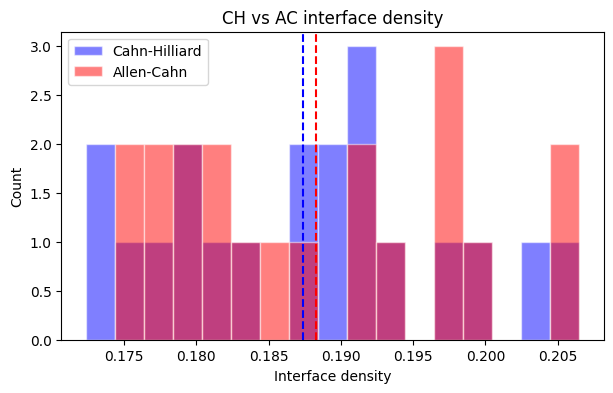

In [2]:
ch_mask = meta["family"] == "cahn_hilliard"     # separating data based on families, boolean mask (true for CH rows, false for AC rows)
ac_mask = meta["family"] == "allen_cahn"        # boolean mask for AC data

ch_vals = meta[ch_mask]["interface_density"].values  # takes only interface density, converts to numpy array
ac_vals = meta[ac_mask]["interface_density"].values

min_val = min(ch_vals.min(), ac_vals.min())        # finding overlap using histogram intersection
max_val = max(ch_vals.max(), ac_vals.max())

bins = np.linspace(min_val, max_val, 18)           # define bins based on min and max of both, spacing is (max_val - min_val) / 17, so that we have 17 intervals and 18 edges.      


ch_hist, _ = np.histogram(ch_vals, bins=bins, density=True)    #histrogram, denisty+true gives normalized histogram (area under it is 1)
ac_hist, _ = np.histogram(ac_vals, bins=bins, density=True)

overlap = np.sum(np.minimum(ch_hist, ac_hist)) * (bins[1] - bins[0]) # basically take the minimum value of both histograms, as that represents the common part in that bin. Then multiply by bin width.

print("CH interface density mean:", round(ch_vals.mean(), 4),      
      ", std:", round(ch_vals.std(), 4))
print("AC interface density mean:", round(ac_vals.mean(), 4),
      ", std:", round(ac_vals.std(), 4))
print("Overlap score:", round(overlap, 3), "(1 means complete overlap)")

fig, ax = plt.subplots(figsize=(7, 4))                     

ax.hist(ch_vals, bins=bins, alpha=0.5, color="blue",
        label="Cahn-Hilliard", edgecolor="white")
ax.hist(ac_vals, bins=bins, alpha=0.5, color="red",
        label="Allen-Cahn", edgecolor="white")

ax.axvline(ch_vals.mean(), color="blue", linestyle="--")    
ax.axvline(ac_vals.mean(), color="red", linestyle="--")

ax.set_xlabel("Interface density")
ax.set_ylabel("Count")
ax.set_title("CH vs AC interface density")

ax.legend()
plt.show()

### Observations

The interface density distribution of both families are overlaping quiet substantially. So, a scalar threshold on features like Interface densities alone 
cannot reliably segregate a microstructure to its correct family.

Additional scalar descriptors (e.g area fraction or nn correlation proxy) are expected to exhibit similar overlap, as they do not capture spatial correlations, which are needed to distinguish underlying evolution mechanisms of families.

Thus low order physical descriptors like this are insufficient to identify the 
underlying evolution law. This motivates the SVD/PCA analysis.

## 2)  Building and centering the image matrix

Now we flatten each image into a row vector and stack these vectors into a matrix X. 
We then compute the mean and subtract it from every row, basically centering, 
and it is what turns plain SVD into PCA.

In [3]:
all_images  = ch_images + ac_images                              #making image matrix from list of 2D arrays
X_raw       = np.array([img.ravel() for img in all_images])     #shape (n_samples, n_pixels)
n_samples, n_pixels = X_raw.shape
nx_img = all_images[0].shape[0]                                  #image side length

print(f"No.of samples: {n_samples}")
print(f"pixels per image:{n_pixels}({nx_img} x {nx_img})")
print(f"Image matrix shape: {X_raw.shape}")

mean_image = X_raw.mean(axis=0)     #compute mean image 
X_centered = X_raw - mean_image        #subtract mean from every row, essential for capturing variance

No.of samples: 40
pixels per image:16384(128 x 128)
Image matrix shape: (40, 16384)


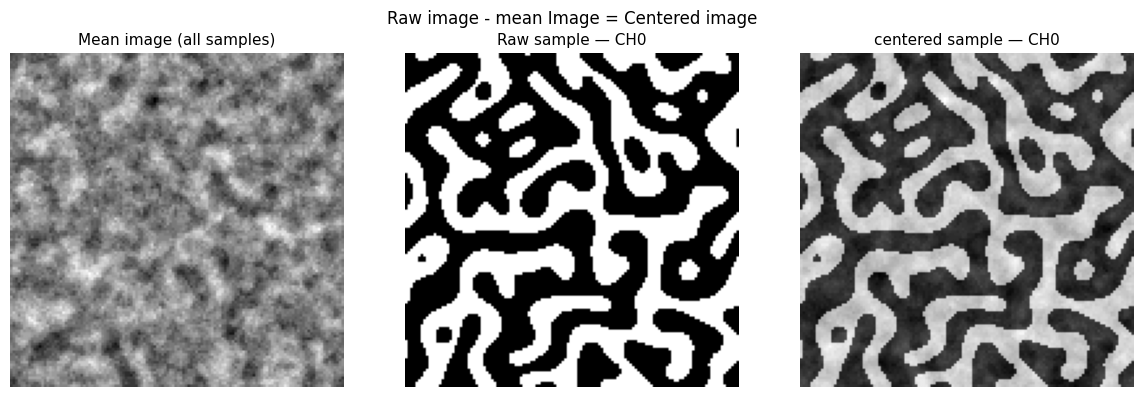

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mean_image.reshape(nx_img, nx_img), cmap="gray", origin="lower")
axes[0].set_title("Mean image (all samples)", fontsize=11)
axes[0].axis("off")

axes[1].imshow(X_raw[0].reshape(nx_img, nx_img), cmap="gray", origin="lower")
axes[1].set_title("Raw sample — CH0", fontsize=11)
axes[1].axis("off")

axes[2].imshow(X_centered[0].reshape(nx_img, nx_img), cmap="gray", origin="lower")
axes[2].set_title("centered sample — CH0", fontsize=11)
axes[2].axis("off")

plt.suptitle("Raw image - mean Image = Centered image", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
print(f"Mean of raw matrix: {X_raw.mean()}") 
print(f"Mean of centered matrix : {X_centered.mean()}  (has to be ~0 obviously)")

Mean of raw matrix: 0.45001220703125
Mean of centered matrix : -8.456776945386934e-19  (has to be ~0 obviously)


### Observation

The mean image appears roughly uniform gray, mainly because both families have similar area fraction, so bright and dark pixels balance out.

The centered sample (CH0 - mean) shows deviations from this average (bright is where CH0 has more phase than average, dark is for less) 
This residual structure is what PCA will decompose in the next section.

Note, the mean of the centered matrix is zero, confirming that our centering is correct.

## 3) SVD and scree plots

We decompose the centered image matrix X using SVD. Scree plot of singular values tells us how many modes capture actually meaningful variance and thus how many dimensions we would need to describe the difference between underlying physics (CH and AC).

In [6]:
U_raw, S_raw, Vt_raw = np.linalg.svd(X_raw, full_matrices=False)   #SVD on raw data (no centering)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)       #SVD on centered data (basically PCA)

#Basic explaination: U - scores where each sample is along each mode; S - singular values (how much each mode contributes to variance); Vt - principal modes (characteristic patterns)

print(f"U  shape : {U.shape} — one row per sample")
print(f"S  shape : {S.shape} — one singular value per mode")
print(f"Vt shape : {Vt.shape}  — one row per mode (principal direction)")

U  shape : (40, 40) — one row per sample
S  shape : (40,) — one singular value per mode
Vt shape : (40, 16384)  — one row per mode (principal direction)


In [7]:
var_explained_raw = (S_raw ** 2) /np.sum(S_raw**2)    # Variance explained by each mode
var_explained     = (S**2)  /np.sum(S**2)

cumvar_raw = np.cumsum(var_explained_raw)
cumvar     = np.cumsum(var_explained)
n_modes_to_plot = 40      #40 samples

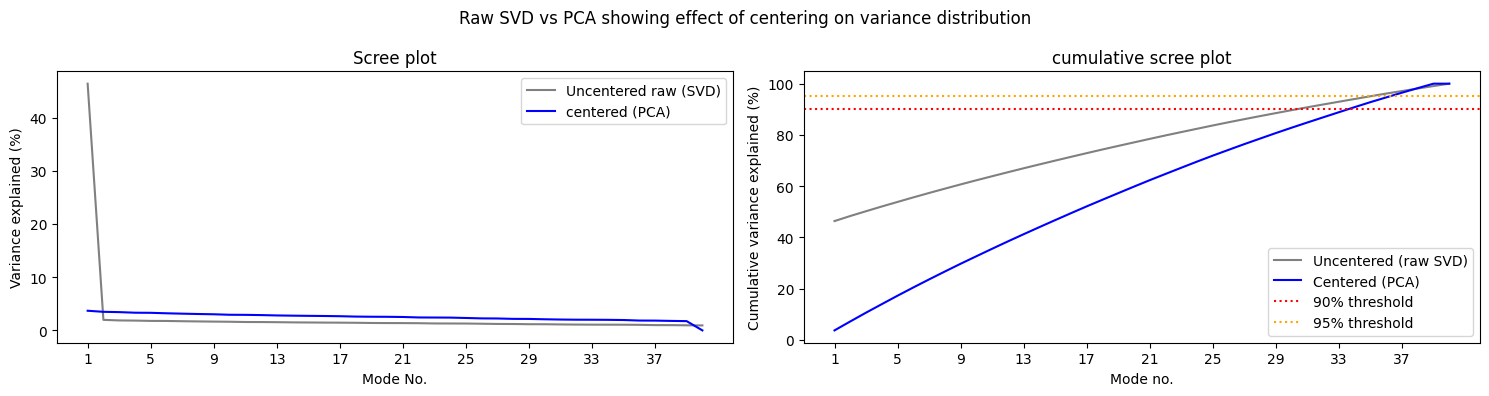

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(range(1, n_modes_to_plot + 1), var_explained_raw[:n_modes_to_plot] * 100,    #individual variance graph
              color="gray",label="Uncentered raw (SVD)")
axes[0].plot(range(1, n_modes_to_plot + 1), var_explained[:n_modes_to_plot] * 100,
               color="blue", label="centered (PCA)")

axes[0].set_xlabel("Mode No.")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot")
axes[0].legend()
axes[0].set_xticks(range(1, n_modes_to_plot + 1, 4))

axes[1].plot(range(1, n_modes_to_plot + 1), cumvar_raw[:n_modes_to_plot] * 100,  #cumulative variance plot
              color="gray", label="Uncentered (raw SVD)")
axes[1].plot(range(1, n_modes_to_plot + 1), cumvar[:n_modes_to_plot] * 100,
               color="blue",label="Centered (PCA)")

axes[1].axhline(90, color="red", linestyle=":", label="90% threshold")
axes[1].axhline(95, color="orange", linestyle=":", label="95% threshold")

axes[1].set_xlabel("Mode no.")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("cumulative scree plot")
axes[1].legend()
axes[1].set_xticks(range(1, n_modes_to_plot + 1, 4))

plt.suptitle("Raw SVD vs PCA showing effect of centering on variance distribution")
plt.tight_layout()
plt.show()

In [9]:
for threshold in [0.80, 0.90, 0.95]:
    n_modes = np.searchsorted(cumvar, threshold) + 1
    print(f"Modes needed to explain {int(threshold*100)}% variance (PCA): {n_modes}")

print(f"\nVariance explained by first mode:")
print(f"  Raw SVD : {var_explained_raw[0]*100:.2f}%  ← dominated by mean image")
print(f"  PCA     : {var_explained[0]*100:.2f}%  ← genuine structural variation")

Modes needed to explain 80% variance (PCA): 29
Modes needed to explain 90% variance (PCA): 34
Modes needed to explain 95% variance (PCA): 37

Variance explained by first mode:
  Raw SVD : 46.36%  ← dominated by mean image
  PCA     : 3.69%  ← genuine structural variation


### Observations

The uncentered SVD concentrates almost a lot of variance in the first mode, this can be slightly deceiving as this mode is simply capturing the mean image and not any meaningful difference between families. 
Thus we know that centering is important.

After centering, variance is distributed more evenly across top modes. The scree plot shows dip after which additional modes contribute diminishing returns. The number of modes needed to explain 90 to 95% of variance basically gives us effective dimensionality of our microstructure dataset.

A low effective dimensionality would mean that despite images having thousands of pixels, the meaningful morphological variation between CH and AC lives in just a handful of directions. 
This is shown in a much better way in part 4.

## 4) Answering how do the principal modes look like using Eigneimages

Here we reshape the top principal directions from SVD back into 2D images (eigenimages). We then figure out what morphological feature each mode is capturing, and confirm it by reconstructing a sample image using increasing numbers of modes.

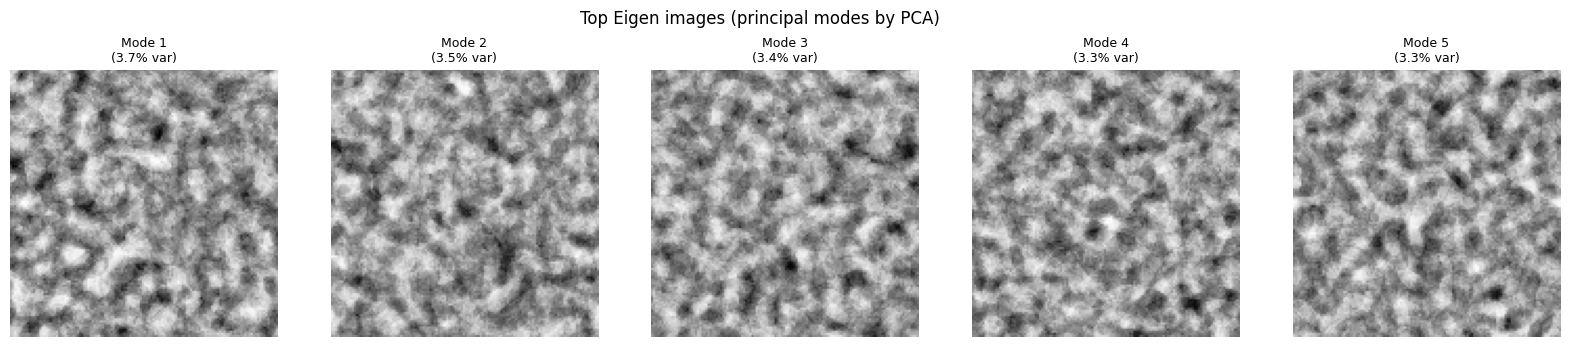

In [10]:
n_modes_to_show = 5 #play around with this number to vary no.of modes

fig, axes = plt.subplots(1, n_modes_to_show, figsize=(20, 4))
fig.suptitle("Top Eigen images (principal modes by PCA)")

for i in range(n_modes_to_show):     #reshape the i'th mode back to image shape (reconstruction)
    mode_img = Vt[i].reshape(nx_img, nx_img)
    ax = axes[i]
    im = ax.imshow(mode_img, cmap="Greys", origin="lower",
                   vmin=-np.abs(mode_img).max(),
                   vmax= np.abs(mode_img).max())
    ax.set_title(f"Mode {i+1}\n({var_explained[i]*100:.1f}% var)", fontsize=9)
    ax.axis("off")  
plt.show()

#Here we can see how leading principle modes look like when regenerated.

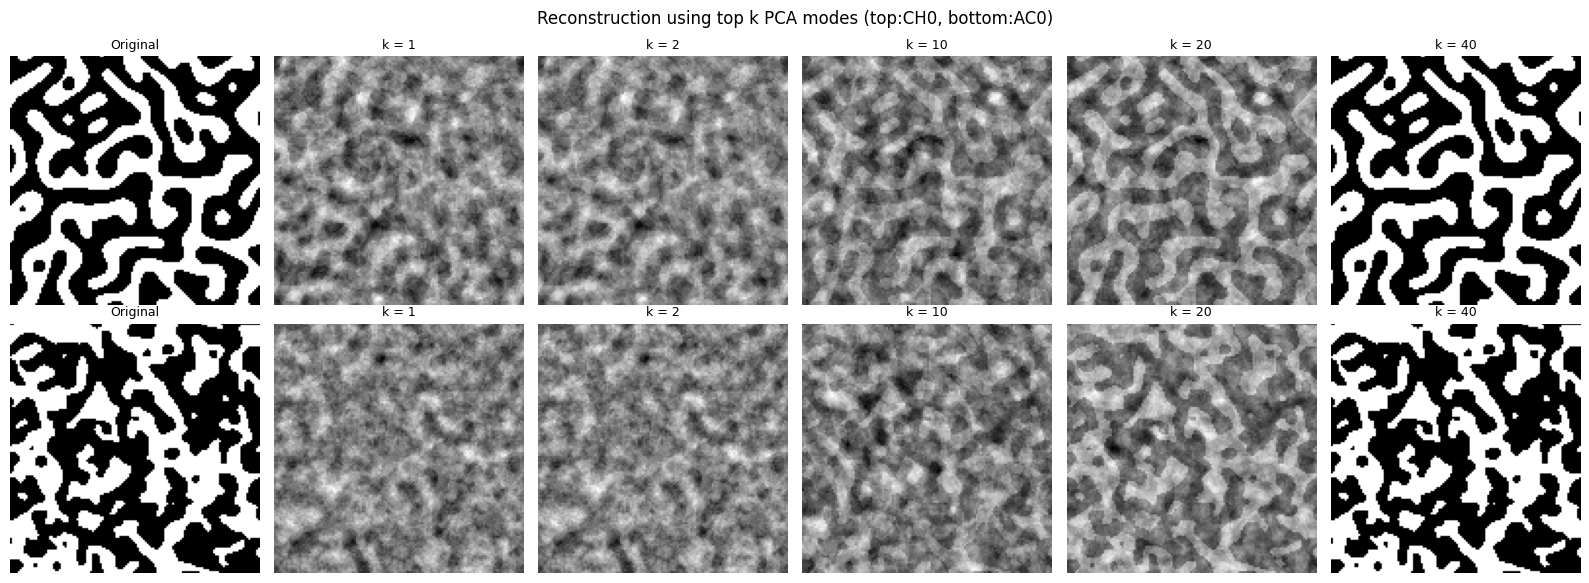

In [11]:
#Reconstructing CH and AC by increasing number of modes (progressively)
sample_ch_idx = 0
sample_ac_idx = len(ch_images)

k_values = [1, 2, 10, 20, len(S)]

fig, axes = plt.subplots(2, len(k_values) + 1, figsize=(16, 6))
fig.suptitle("Reconstruction using top k PCA modes (top:CH0, bottom:AC0)")

for row,sample_idx in enumerate([sample_ch_idx, sample_ac_idx]):
    label = "CH0" if row == 0 else "AC0"

    axes[row, 0].imshow(X_raw[sample_idx].reshape(nx_img, nx_img),    #inital image
                        cmap="gray", origin="lower")
    axes[row, 0].set_title("Original", fontsize=9)
    axes[row, 0].axis("off")

    for col, k in enumerate(k_values):
        # reconstruct: mean + sum of top k modes weighted by scores
        scores     = U[sample_idx, :k] * S[:k]          # shape (k,)
        recon      = mean_image + scores @ Vt[:k, :]     # shape (n_pixels,)
        recon_img  = recon.reshape(nx_img, nx_img)

        axes[row, col + 1].imshow(recon_img, cmap="gray", origin="lower")
        axes[row, col + 1].set_title(f"k = {k}", fontsize=9)
        axes[row, col + 1].axis("off")

plt.tight_layout()
plt.show()

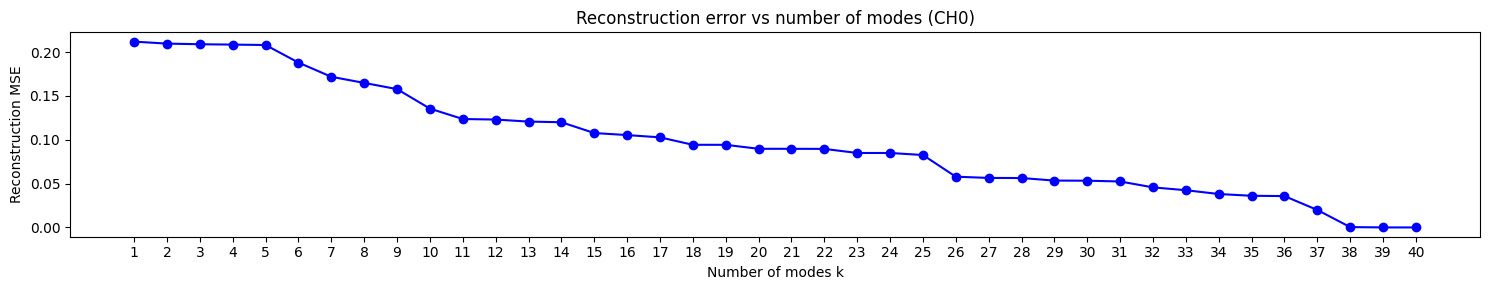

In [12]:
sample_idx = 0   # CH0
errors = []

for k in range(1, len(S) + 1):
    scores = U[sample_idx, :k] * S[:k]
    recon  = mean_image + scores @ Vt[:k, :]
    mse    = np.mean((X_raw[sample_idx] - recon) ** 2)
    errors.append(mse)

plt.figure(figsize=(15, 3))
plt.plot(range(1, len(S) + 1), errors, 'o-', color="blue")
plt.xlabel("Number of modes k")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction error vs number of modes (CH0)")
plt.xticks(range(1, len(S) + 1))
plt.tight_layout()
plt.show()

#This basically shows how quickly the variance is captured by top modes.

### Observation

**Eigenimages:** The first Eigenimage captures the most prominent structural 
difference between samples which is likely to be a large scale connectivity or domain arrangement. 

Later modes capture comparetively finer spatial features.

**Reconstruction :** With very few modes (k = 1 or 2) the reconstruction is blurry and approximate. As k increases the image sharpens and finer details are recovered. 

The reconstruction graph visualizes how quickly the error drops, if a rapid drop is observed (here between 4 and 5 modes), we can say dataset has low effective dimensionality and that the leading modes carry most of the meaningful structure.

## 5) How do we know that CH and AC families seperate in this space? (PCA) 

We project all samples onto the top principal components. Earlier, after performing SVD we got the matrix Vt, this is the principal directions in pixel space.

Basically, instead of describing a microstructure as 1000s of pixel values, we can now describe it as around 3 numbers which are its scores on PC1, PC2, PC3.

Our central motto is to show that full field dimensionality reduction reveals structure that scalar statistics actually missed.

In [13]:
ch_indices = list(range(len(ch_images)))
ac_indices = list(range(len(ch_images), len(ch_images) + len(ac_images)))

# Row is a sample, column is PC

scores = U * S     # shape(n_samples, n_modes)   

#u tells us where each sample sits in the PC space ; s tells how important each PC is, larger means that direction captures more variance in the dataset.

ch_scores = scores[ch_indices]   #shape (n_ch, n_modes)
ac_scores = scores[ac_indices]   #shape (n_ac, n_modes)

print(f"Scores matrix shape : {scores.shape}")
print(f"CH scores shape     : {ch_scores.shape}")
print(f"AC scores shape     : {ac_scores.shape}")

Scores matrix shape : (40, 40)
CH scores shape     : (20, 40)
AC scores shape     : (20, 40)


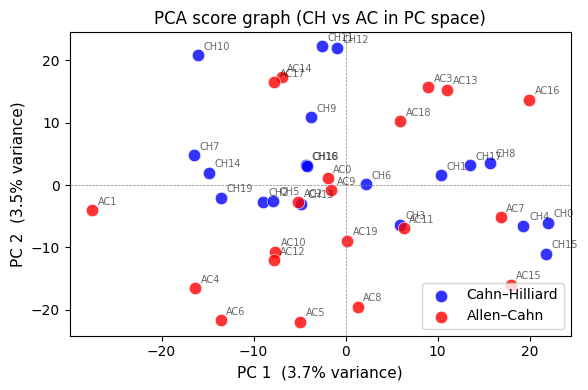

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(ch_scores[:, 0], ch_scores[:, 1],       
           color="blue", s=80, alpha=0.8,
           label="Cahn–Hilliard", edgecolors="white", linewidths=0.5)
ax.scatter(ac_scores[:, 0], ac_scores[:, 1],
           color="red", s=80, alpha=0.8,
           label="Allen–Cahn", edgecolors="white", linewidths=0.5)

# annotate each point with its sample id
for i, idx in enumerate(ch_indices):
    ax.annotate(f"CH{i}", (ch_scores[i, 0], ch_scores[i, 1]),
                fontsize=7, alpha=0.6, xytext=(4, 4), textcoords="offset points")
for i, idx in enumerate(ac_indices):
    ax.annotate(f"AC{i}", (ac_scores[i, 0], ac_scores[i, 1]),
                fontsize=7, alpha=0.6, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel(f"PC 1  ({var_explained[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC 2  ({var_explained[1]*100:.1f}% variance)", fontsize=11)
ax.set_title("PCA score graph (CH vs AC in PC space)", fontsize=12)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

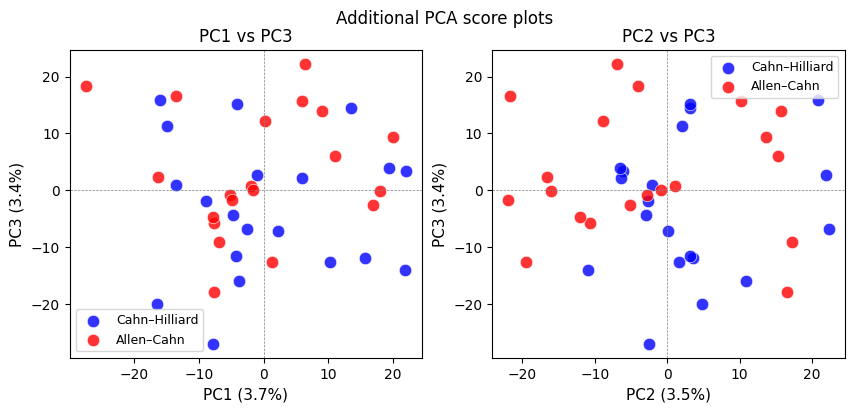

In [16]:
#As the first two PCs may not capture all the structure, so let's also try to look at PC1vsPC3, PC2vsPC3.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pairs = [(0, 2), (1, 2)]

for ax, (i, j) in zip(axes, pairs):
    ax.scatter(ch_scores[:, i], ch_scores[:, j],
               color="blue", s=80, alpha=0.8,
               label="Cahn–Hilliard", edgecolors="white", linewidths=0.5)
    ax.scatter(ac_scores[:, i], ac_scores[:, j],
               color="red", s=80, alpha=0.8,
               label="Allen–Cahn", edgecolors="white", linewidths=0.5)
    ax.set_xlabel(f"PC{i+1} ({var_explained[i]*100:.1f}%)", fontsize=11)
    ax.set_ylabel(f"PC{j+1} ({var_explained[j]*100:.1f}%)", fontsize=11)
    ax.set_title(f"PC{i+1} vs PC{j+1}", fontsize=12)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.legend(fontsize=9)

plt.suptitle("Additional PCA score plots", fontsize=12)
plt.show()

In [17]:
ch_centroid = ch_scores.mean(axis=0)     #centroid of both families in PC space
ac_centroid = ac_scores.mean(axis=0)

n_dims = 15     #using top 15 PCs to find distance and spread
centroid_dist = np.linalg.norm(ch_centroid[:n_dims] - ac_centroid[:n_dims])

ch_spread = ch_scores[:, :n_dims].std(axis=0).mean() #Average spread along Pc1 and Pc2
ac_spread = ac_scores[:, :n_dims].std(axis=0).mean()

avg_spread = (ch_spread + ac_spread) / 2      #This will be our criterion for how well can families be seperated in this 2D PC space

separation_ratio = centroid_dist / avg_spread

print(f"CH centroid (PC1, PC2) : ({ch_centroid[0]:.3f}, {ch_centroid[1]:.3f})")
print(f"AC centroid (PC1, PC2) : ({ac_centroid[0]:.3f}, {ac_centroid[1]:.3f})")
print(f"Centroid distance      : {centroid_dist:.3f}")
print(f"Average within-family spread : {avg_spread:.3f}\n")
print(f"Separation ratio       : {separation_ratio:.3f}\n")
print("If separation ratio > 1 means the families are further apart than their individual spreads, basically PCA has found a meaningful inter family axis.")

CH centroid (PC1, PC2) : (0.625, 2.866)
AC centroid (PC1, PC2) : (-0.625, -2.866)
Centroid distance      : 14.947
Average within-family spread : 10.814

Separation ratio       : 1.382

If separation ratio > 1 means the families are further apart than their individual spreads, basically PCA has found a meaningful inter family axis.


### Observation

**Scatter plot:** The two families form distinct clusters in the PC1–PC2 plane — 
a separation that was completely invisible in the scalar feature space of Section 1. 
This confirms that the full image fields carry information about the underlying 
evolution law that low-order statistics discard.

**Separation ratio:** Greater than 1 means the inter family distance exceeds 
the typical within family spread. Thus the 2 clouds are genuinely separated, not merely 
offset by noise. **This is the answer to the central question of my project.**